In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shutil
import os
import glob as gb
import tensorflow as tf
from tensorflow.keras.models import Sequential
from zipfile import ZipFile
import cv2

In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"neazmulmowla","key":"4de5c90d906abdb230deeb9eb4a91aca"}'}

In [3]:
!mkdir ~/.kaggle
!touch ~/.kaggle/kaggle.json

api_token = [("username", "neazmulmowla"), ("key", "4de5c90d906abdb230deeb9eb4a91aca")]
api_token_dict = dict(api_token)

import json

with open('/root/.kaggle/kaggle.json', 'w') as file:
    json.dump(api_token_dict, file)

!chmod 600 ~/.kaggle/kaggle.json

print('complete')

complete


In [4]:
!kaggle datasets download -d neazmulmowla/arsenic

Dataset URL: https://www.kaggle.com/datasets/neazmulmowla/arsenic
License(s): unknown
 99% 3.27G/3.29G [00:26<00:00, 253MB/s]
100% 3.29G/3.29G [00:27<00:00, 131MB/s]


In [5]:
from zipfile import ZipFile
file_name = '/content/arsenic.zip'

with ZipFile(file_name, 'r') as zip:
  zip.extractall()
  print('complete')

complete


In [6]:
from PIL import Image
import matplotlib.pyplot as plt
base_path = '/content/ArsenicSkinImageBD/Augmented'

In [7]:
# Load and process dataset
dataset_path = base_path
image_data = []
folders = {'infected': 1, 'not_infected': 2}

for folder_name, label in folders.items():
    folder_path = os.path.join(dataset_path, folder_name)
    if os.path.exists(folder_path):
        image_files = os.listdir(folder_path)
        for image_file in image_files:
            image_data.append((os.path.join(folder_path, image_file), label))
    else:
        print(f"Folder {folder_path} not found.")

df = pd.DataFrame(image_data, columns=['image_path', 'label'])

In [8]:
# Check the number of images per class
class_counts = df.groupby('label').size().reset_index(name='count')

# Display the results
print("Number of images per class:")
print(class_counts)

Number of images per class:
   label  count
0      1   4446
1      2   4446


/tmp/ipython-input-9-517141223.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=class_counts, x='Class', y='ImageCount', palette="viridis")


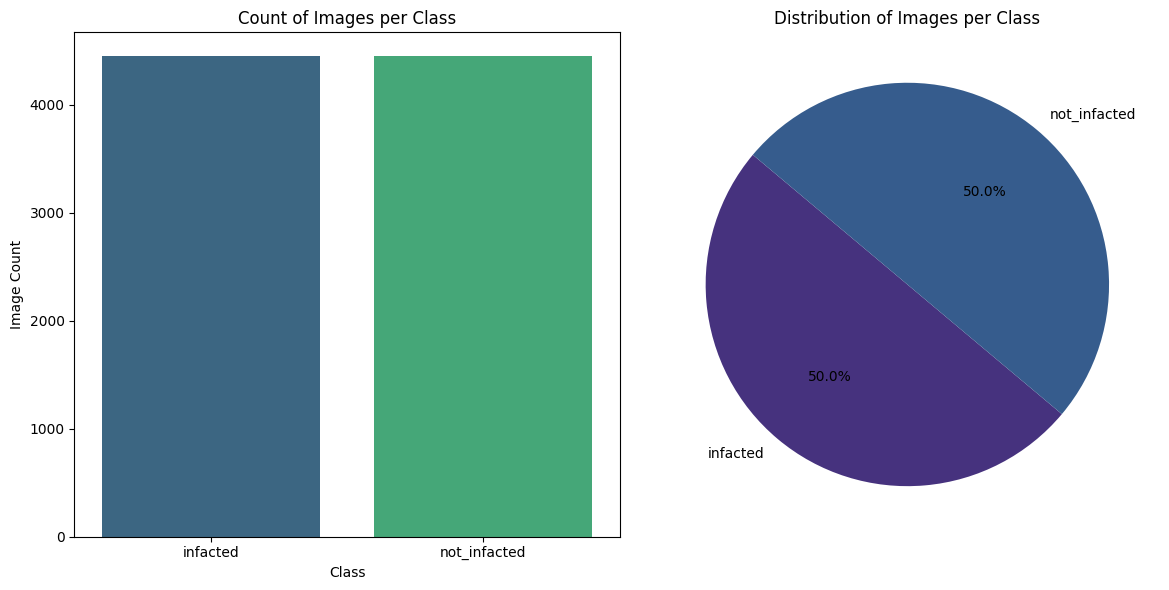

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Count the number of images per class
class_counts = df.groupby('label').size().reset_index(name='ImageCount')

# Map real class names to labels
class_names = {1: 'infacted', 2: 'not_infacted'}
class_counts['Class'] = class_counts['label'].map(class_names)

# Plot the bar chart and pie chart
plt.figure(figsize=(12, 6))

# Bar chart
plt.subplot(1, 2, 1)
sns.barplot(data=class_counts, x='Class', y='ImageCount', palette="viridis")
plt.title('Count of Images per Class')
plt.ylabel('Image Count')
plt.xlabel('Class')

# Pie chart
plt.subplot(1, 2, 2)
plt.pie(class_counts['ImageCount'], labels=class_counts['Class'], autopct='%1.1f%%', startangle=140, colors=sns.color_palette("viridis"))
plt.title('Distribution of Images per Class')

plt.tight_layout()
plt.show()

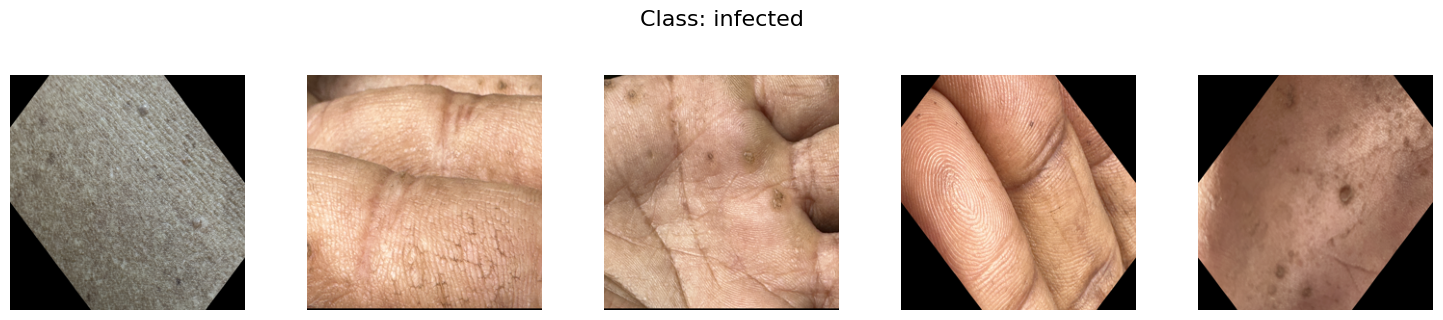

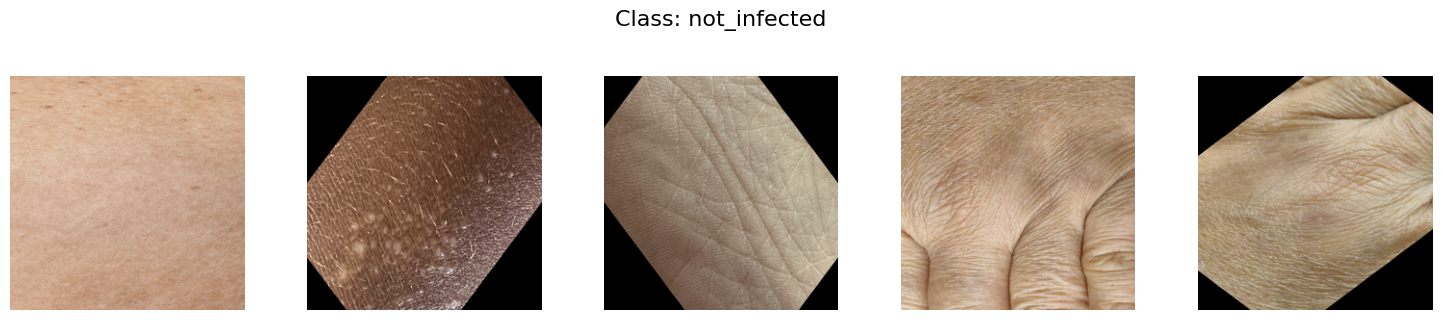

In [10]:
import os
import matplotlib.pyplot as plt
from PIL import Image

# Define class names
classes = ['infected', 'not_infected']

# Base path of the dataset
base_path = dataset_path  # Replace with your actual dataset path

# Loop through each class and display 5 images
for class_name in classes:
    folder_path = os.path.join(base_path, class_name)
    if not os.path.exists(folder_path):
        print(f"Folder not found: {folder_path}")
        continue

    # Get the first 5 image files
    image_files = [f for f in os.listdir(folder_path) if f.endswith(('.png', '.jpg', '.jpeg'))][:5]

    # Plot images
    plt.figure(figsize=(15, 3))
    plt.suptitle(f"Class: {class_name}", fontsize=16, y=1.05)

    for i, image_file in enumerate(image_files):
        image_path = os.path.join(folder_path, image_file)
        try:
            image = Image.open(image_path)
            plt.subplot(1, 5, i + 1)
            plt.imshow(image)
            plt.axis('off')
        except Exception as e:
            print(f"Error loading image {image_path}: {e}")

    plt.tight_layout()
    plt.show()


In [11]:
df.head()

,image_path,label
0,/content/ArsenicSkinImageBD/Augmented/infected...,1
1,/content/ArsenicSkinImageBD/Augmented/infected...,1
2,/content/ArsenicSkinImageBD/Augmented/infected...,1
3,/content/ArsenicSkinImageBD/Augmented/infected...,1
4,/content/ArsenicSkinImageBD/Augmented/infected...,1


In [12]:
df.tail()

,image_path,label
8887,/content/ArsenicSkinImageBD/Augmented/not_infe...,2
8888,/content/ArsenicSkinImageBD/Augmented/not_infe...,2
8889,/content/ArsenicSkinImageBD/Augmented/not_infe...,2
8890,/content/ArsenicSkinImageBD/Augmented/not_infe...,2
8891,/content/ArsenicSkinImageBD/Augmented/not_infe...,2


In [13]:
df.shape

(8892, 2)

In [14]:
df.columns

Index(['image_path', 'label'], dtype='object')

In [15]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import Xception
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, BatchNormalization, Input  # Explicitly import Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


In [16]:
from imblearn.over_sampling import RandomOverSampler

In [17]:
ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(df[['image_path']], df['label'])

In [18]:
df_resampled = pd.DataFrame(X_resampled, columns=['image_path'])
df_resampled['label'] = y_resampled

In [19]:
print("\nClass distribution after oversampling:")
print(df_resampled['label'].value_counts())


Class distribution after oversampling:
label
1    4446
2    4446
Name: count, dtype: int64


In [20]:
df_resampled

,image_path,label
0,/content/ArsenicSkinImageBD/Augmented/infected...,1
1,/content/ArsenicSkinImageBD/Augmented/infected...,1
2,/content/ArsenicSkinImageBD/Augmented/infected...,1
3,/content/ArsenicSkinImageBD/Augmented/infected...,1
4,/content/ArsenicSkinImageBD/Augmented/infected...,1
...,...,...
8887,/content/ArsenicSkinImageBD/Augmented/not_infe...,2
8888,/content/ArsenicSkinImageBD/Augmented/not_infe...,2
8889,/content/ArsenicSkinImageBD/Augmented/not_infe...,2
8890,/content/ArsenicSkinImageBD/Augmented/not_infe...,2


In [21]:
import time
import shutil
import pathlib
import itertools
from PIL import Image

import cv2
import seaborn as sns
sns.set_style('darkgrid')
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation, Dropout, BatchNormalization
from tensorflow.keras import regularizers

import warnings
warnings.filterwarnings("ignore")

print ('check')

check


In [22]:
df_resampled['label'] = df_resampled['label'].astype(str)

In [23]:
train_df_new, temp_df_new = train_test_split(
    df_resampled,
    train_size=0.8,
    shuffle=True,
    random_state=42,
    stratify=df_resampled['label']
)

valid_df_new, test_df_new = train_test_split(
    temp_df_new,
    test_size=0.5,
    shuffle=True,
    random_state=42,
    stratify=temp_df_new['label']
)

In [24]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

batch_size = 16
img_size = (299, 299)
channels = 3
img_shape = (img_size[0], img_size[1], channels)

tr_gen = ImageDataGenerator(rescale=1./255)
ts_gen = ImageDataGenerator(rescale=1./255)

train_gen_new = tr_gen.flow_from_dataframe(
    train_df_new,
    x_col='image_path',
    y_col='label',
    target_size=img_size,
    class_mode='sparse',
    color_mode='rgb',
    shuffle=True,
    batch_size=batch_size
)

valid_gen_new = ts_gen.flow_from_dataframe(
    valid_df_new,
    x_col='image_path',
    y_col='label',
    target_size=img_size,
    class_mode='sparse',
    color_mode='rgb',
    shuffle=True,
    batch_size=batch_size
)

test_gen_new = ts_gen.flow_from_dataframe(
    test_df_new,
    x_col='image_path',
    y_col='label',
    target_size=img_size,
    class_mode='sparse',
    color_mode='rgb',
    shuffle=False,
    batch_size=batch_size
)

Found 7113 validated image filenames belonging to 2 classes.
Found 889 validated image filenames belonging to 2 classes.
Found 890 validated image filenames belonging to 2 classes.


In [25]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [26]:
physical_devices = tf.config.list_physical_devices('GPU')
if physical_devices:
    print("Using GPU")
else:
    print("Using CPU")

Using GPU


In [38]:
import tensorflow as tf
from tensorflow.keras.layers import (
    Layer, MultiHeadAttention, GlobalAveragePooling2D, Dense,
    Concatenate, SeparableConv2D, MaxPooling2D, BatchNormalization,
    ReLU, Dropout, Input, Add, Conv2D, Activation
)
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2

# --- Cross-Context Dual Attention (CCDA) ---
class CCDA(Layer):
    def __init__(self, filters, dilation_rate=2, num_heads=2, **kwargs):
        super().__init__(**kwargs)
        self.filters = filters
        self.dilation_rate = dilation_rate
        self.num_heads = num_heads

    def build(self, input_shape):
        self.dw_conv = SeparableConv2D(
            self.filters, kernel_size=3, dilation_rate=self.dilation_rate,
            padding='same', depthwise_regularizer=l2(1e-4), pointwise_regularizer=l2(1e-4)
        )
        self.mha = MultiHeadAttention(num_heads=self.num_heads, key_dim=input_shape[-1] // self.num_heads)
        super().build(input_shape)

    def call(self, x):
        conv_context = self.dw_conv(x)
        B, H, W, C = tf.shape(x)[0], tf.shape(x)[1], tf.shape(x)[2], tf.shape(x)[3]
        flat_x = tf.reshape(x, [B, H*W, C])
        attn = self.mha(flat_x, flat_x)
        attn = tf.reshape(attn, [B, H, W, C])
        return Add()([conv_context, attn])

# --- CBAM with Variance Pooling ---
class CBAM(Layer):
    def __init__(self, ratio=8, **kwargs):
        super().__init__(**kwargs)
        self.ratio = ratio

    def build(self, input_shape):
        self.C = input_shape[-1]
        self.fc1 = Dense(self.C // self.ratio, activation='relu')
        self.fc2 = Dense(self.C, activation='sigmoid')
        self.conv = Conv2D(1, 7, padding='same', activation='sigmoid')
        super().build(input_shape)

    def call(self, x):
        # Channel attention with mean, max, variance pooling
        gap = tf.reduce_mean(x, axis=[1, 2], keepdims=True)
        gmp = tf.reduce_max(x, axis=[1, 2], keepdims=True)
        gvp = tf.math.reduce_variance(x, axis=[1, 2], keepdims=True)
        cat = tf.concat([gap, gmp, gvp], axis=-1)
        cat = tf.reduce_mean(cat, axis=-1, keepdims=True)  # Shape back to (B,1,1,C)
        attn_c = self.fc2(self.fc1(cat))
        x1 = x * attn_c

        # Spatial attention
        mp = tf.reduce_max(x1, axis=-1, keepdims=True)
        ap = tf.reduce_mean(x1, axis=-1, keepdims=True)
        attn_s = self.conv(tf.concat([mp, ap], axis=-1))
        return x1 * attn_s


# --- Window-based Self Attention ---
class WindowAttention(Layer):
    def __init__(self, window_size=4, num_heads=4, **kwargs):
        super().__init__(**kwargs)
        self.window_size = window_size
        self.num_heads = num_heads

    def build(self, input_shape):
        self.C = input_shape[-1]
        self.mha = MultiHeadAttention(num_heads=self.num_heads, key_dim=self.C // self.num_heads)
        super().build(input_shape)

    def call(self, x):
        B, H, W, C = tf.shape(x)[0], tf.shape(x)[1], tf.shape(x)[2], tf.shape(x)[3]
        pad_h = (self.window_size - H % self.window_size) % self.window_size
        pad_w = (self.window_size - W % self.window_size) % self.window_size
        x_padded = tf.pad(x, [[0,0],[0,pad_h],[0,pad_w],[0,0]])
        H_pad, W_pad = H + pad_h, W + pad_w

        x_win = tf.reshape(x_padded, [B, H_pad//self.window_size, self.window_size,
                                      W_pad//self.window_size, self.window_size, C])
        x_win = tf.transpose(x_win, [0,1,3,2,4,5])
        x_win = tf.reshape(x_win, [-1, self.window_size*self.window_size, C])

        attn = self.mha(query=x_win, value=x_win)
        x_rec = tf.reshape(attn, [B, H_pad//self.window_size, W_pad//self.window_size,
                                  self.window_size, self.window_size, C])
        x_rec = tf.transpose(x_rec, [0,1,3,2,4,5])
        x_rec = tf.reshape(x_rec, [B, H_pad, W_pad, C])
        return x_rec[:, :H, :W, :]

# --- Gated Attention Fusion (GAF) ---
class GatedFusion(Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def build(self, input_shape):
        self.gate_conv = Conv2D(input_shape[0][-1], 1, activation='sigmoid')
        super().build(input_shape)

    def call(self, inputs):
        x1, x2, x3 = inputs
        gate = self.gate_conv(x1 + x2 + x3)
        fused = gate * x1 + (1 - gate) * x2 + 0.5 * x3
        return fused

# --- Full Model ---
def build_model(input_shape=(299, 299, 3), num_classes=2, l2_reg=1e-4):
    inp = Input(shape=input_shape)
    x = inp

    for filters in [64, 128, 256]:
        x = SeparableConv2D(filters, 3, padding='same',
                            depthwise_regularizer=l2(l2_reg),
                            pointwise_regularizer=l2(l2_reg))(x)
        x = BatchNormalization()(x)
        x = ReLU()(x)
        x = MaxPooling2D()(x)

    attn1 = WindowAttention(window_size=4)(x)
    attn2 = CBAM()(x)
    attn3 = CCDA(filters=256)(x)
    fused = GatedFusion()([attn1, attn2, attn3])

    x = SeparableConv2D(512, 1, padding='same', activation='relu')(fused)
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu', kernel_regularizer=l2(l2_reg))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)  # <-- Dropout after 256-dense
    x = Dense(128, activation='relu', kernel_regularizer=l2(l2_reg))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)  # <-- Dropout after 128-dense
    out = Dense(num_classes, activation='softmax')(x)

    return Model(inp, out)

# Build and compile
model = build_model(num_classes=2)
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [39]:
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 299, 299,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_10 │ (None, 299, 299,  │        283 │ input_layer_2[0]… │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 299, 299,  │        256 │ separable_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_6 (ReLU)      │ (None, 299, 299,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 149, 149,  │          0 │ re_lu_6[0][0]     │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_11 │ (None, 149, 149,  │      8,896 │ max_pooling2d_6[… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 149, 149,  │        512 │ separable_conv2d… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_7 (ReLU)      │ (None, 149, 149,  │          0 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_7     │ (None, 74, 74,    │          0 │ re_lu_7[0][0]     │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_12 │ (None, 74, 74,    │     34,176 │ max_pooling2d_7[… │
│ (SeparableConv2D)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 74, 74,    │      1,024 │ separable_conv2d… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_8 (ReLU)      │ (None, 74, 74,    │          0 │ batch_normalizat… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 37, 37,    │          0 │ re_lu_8[0][0]     │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ window_attention_2  │ (None, 37, 37,    │    263,168 │ max_pooling2d_8[… │
│ (WindowAttention)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cbam_2 (CBAM)       │ (None, 37, 37,    │      8,611 │ max_pooling2d_8[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ccda_2 (CCDA)       │ (None, 37, 37,    │    331,264 │ max_pooling2d_8[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gated_fusion_2      │ (None, 37, 37,    │     65,792 │ window_attention

 Total params: 1,011,840 (3.86 MB)

 Trainable params: 1,010,176 (3.85 MB)

 Non-trainable params: 1,664 (6.50 KB)

In [40]:
# Train with only ReduceLROnPlateau and EarlyStopping
history = model.fit(
    train_gen_new,
    validation_data=valid_gen_new,
    epochs=100,
    callbacks=[
        tf.keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.5, verbose=1),
        tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, verbose=1)
    ]
)


Epoch 1/100
445/445 ━━━━━━━━━━━━━━━━━━━━ 116s 219ms/step - accuracy: 0.7029 - loss: 0.7381 - val_accuracy: 0.4994 - val_loss: 0.8310 - learning_rate: 1.0000e-04
Epoch 2/100
445/445 ━━━━━━━━━━━━━━━━━━━━ 81s 182ms/step - accuracy: 0.8054 - loss: 0.5488 - val_accuracy: 0.8290 - val_loss: 0.5343 - learning_rate: 1.0000e-04
Epoch 3/100
445/445 ━━━━━━━━━━━━━━━━━━━━ 81s 182ms/step - accuracy: 0.8308 - loss: 0.4909 - val_accuracy: 0.8358 - val_loss: 0.4268 - learning_rate: 1.0000e-04
Epoch 4/100
445/445 ━━━━━━━━━━━━━━━━━━━━ 82s 185ms/step - accuracy: 0.8530 - loss: 0.4350 - val_accuracy: 0.7548 - val_loss: 0.6042 - learning_rate: 1.0000e-04
Epoch 5/100
445/445 ━━━━━━━━━━━━━━━━━━━━ 142s 186ms/step - accuracy: 0.8699 - loss: 0.3914 - val_accuracy: 0.8369 - val_loss: 0.4481 - learning_rate: 1.0000e-04
Epoch 6/100
445/445 ━━━━━━━━━━━━━━━━━━━━ 81s 181ms/step - accuracy: 0.8855 - loss: 0.3661 - val_accuracy: 0.9303 - val_loss: 0.2760 - learning_rate: 1.0000e-04
Epoch 7/100
445/445 ━━━━━━━━━━━━━━━━━━

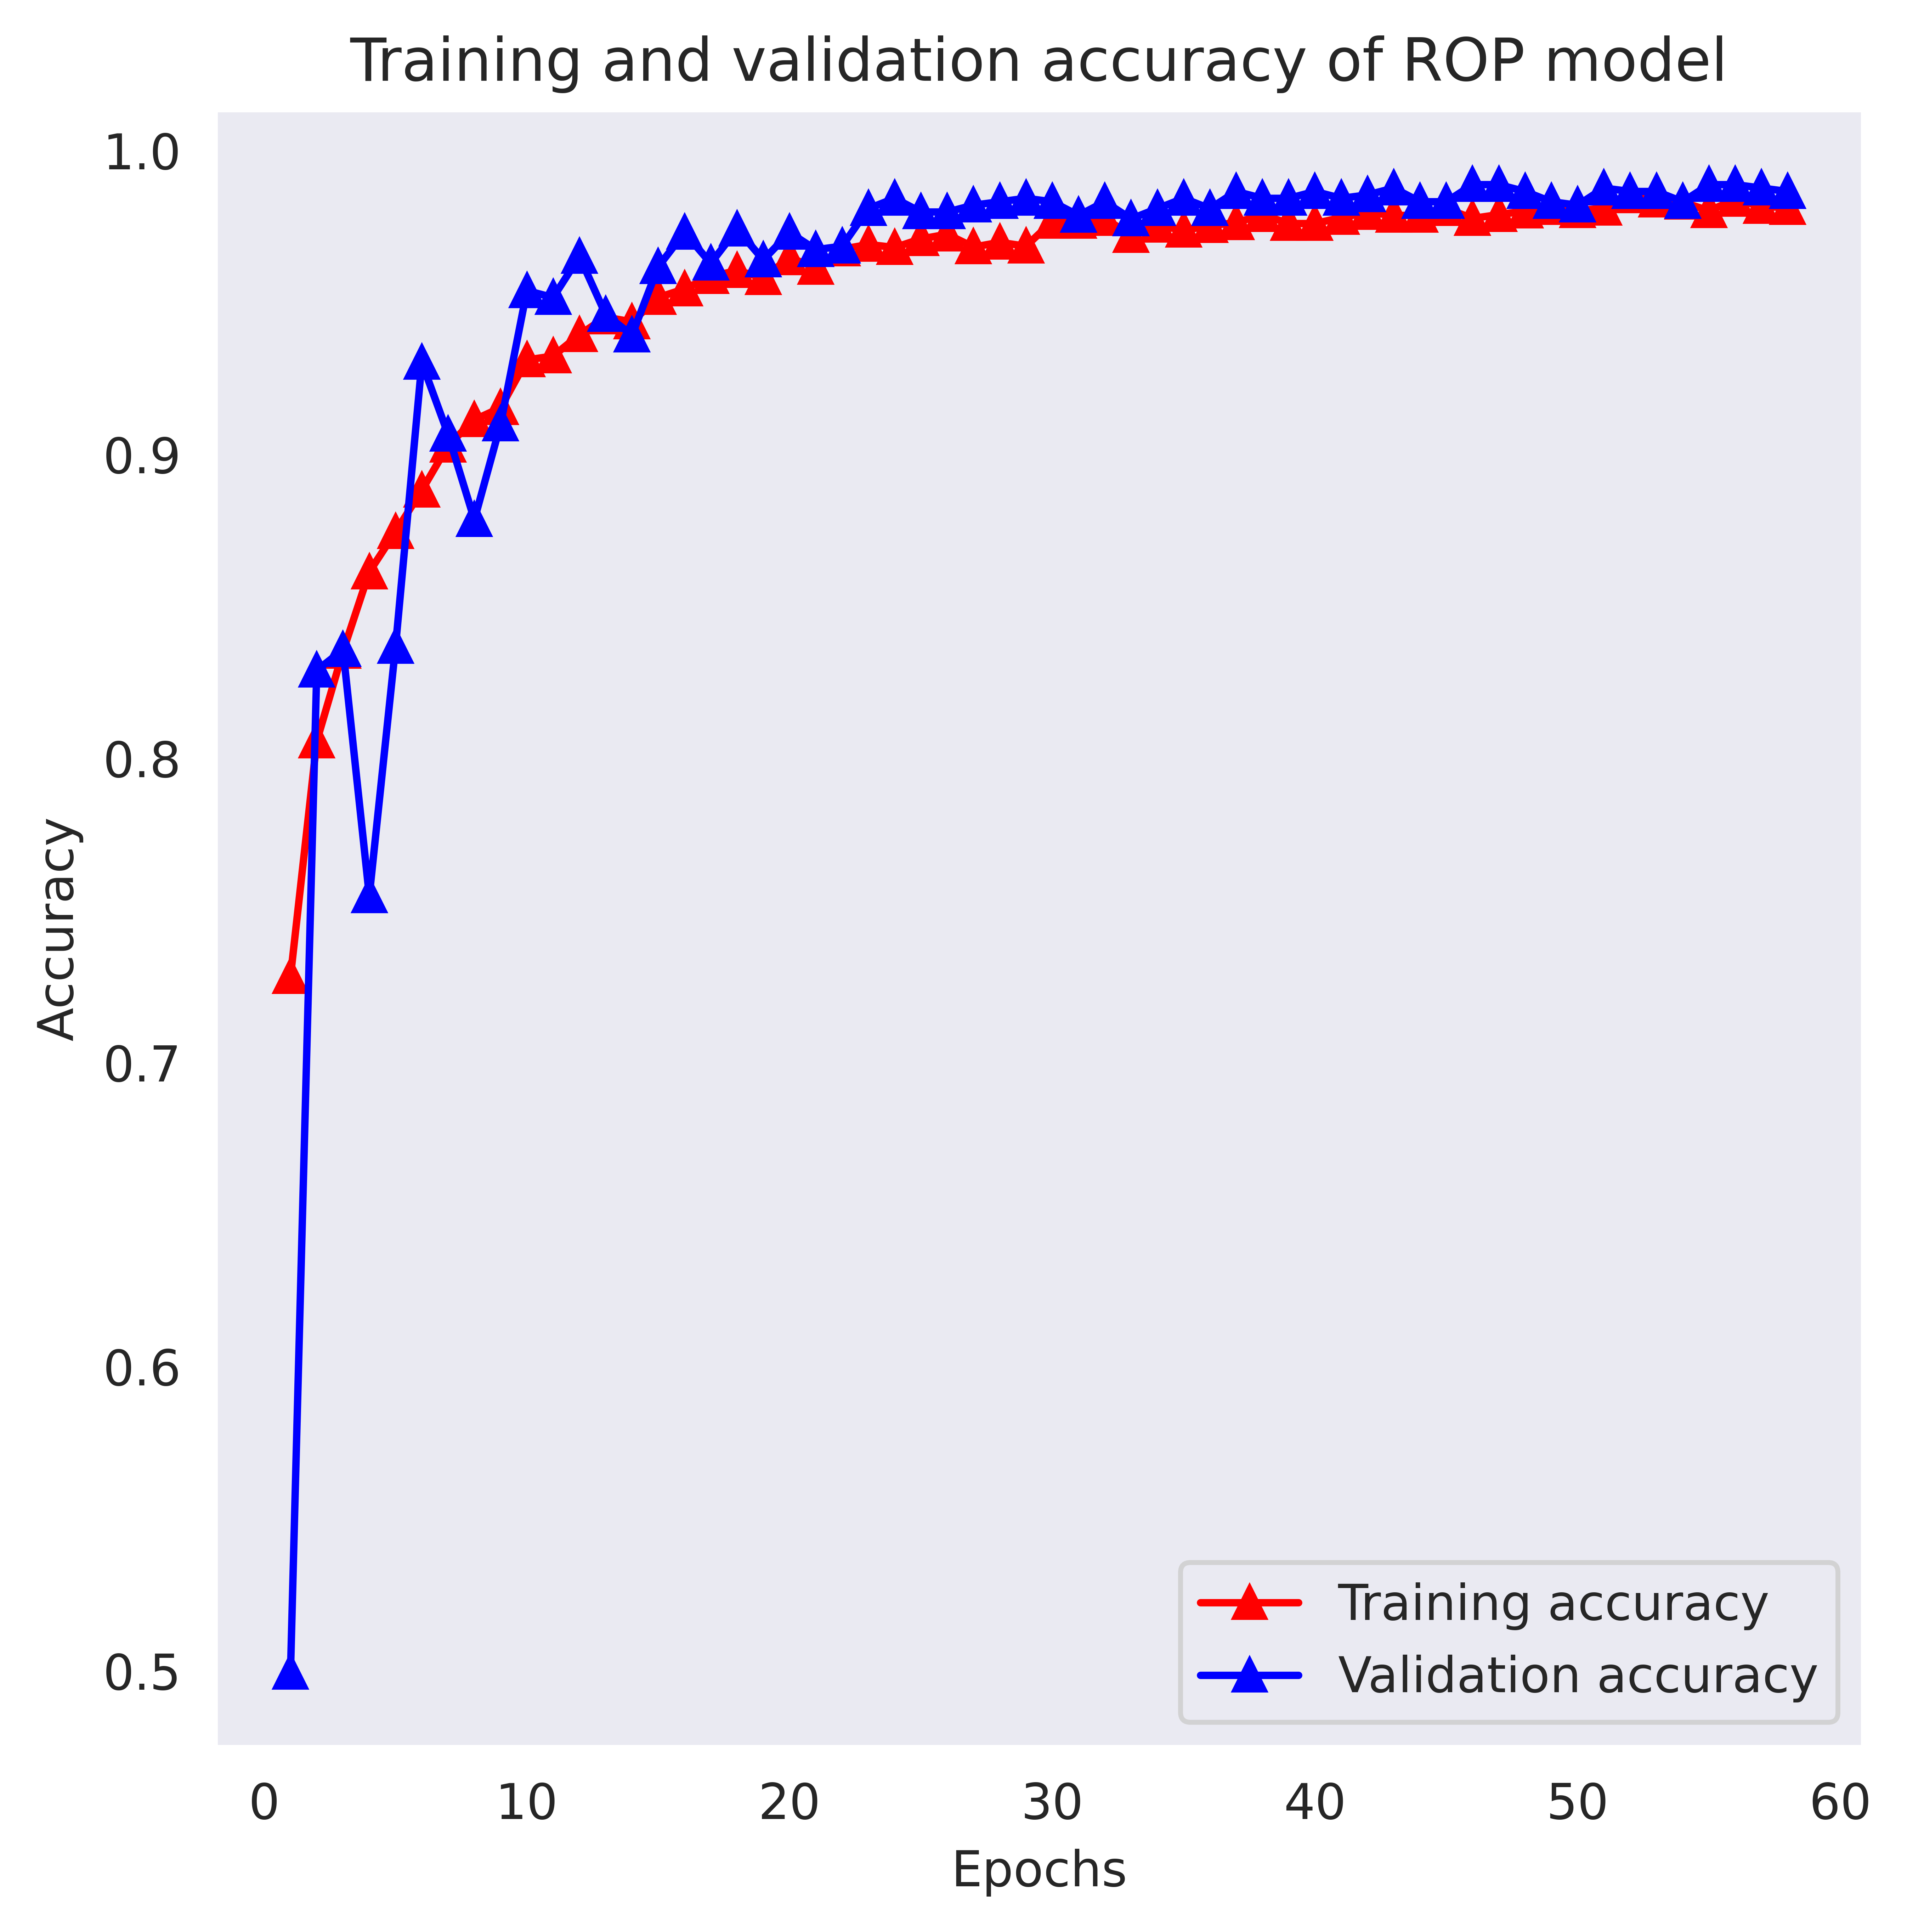

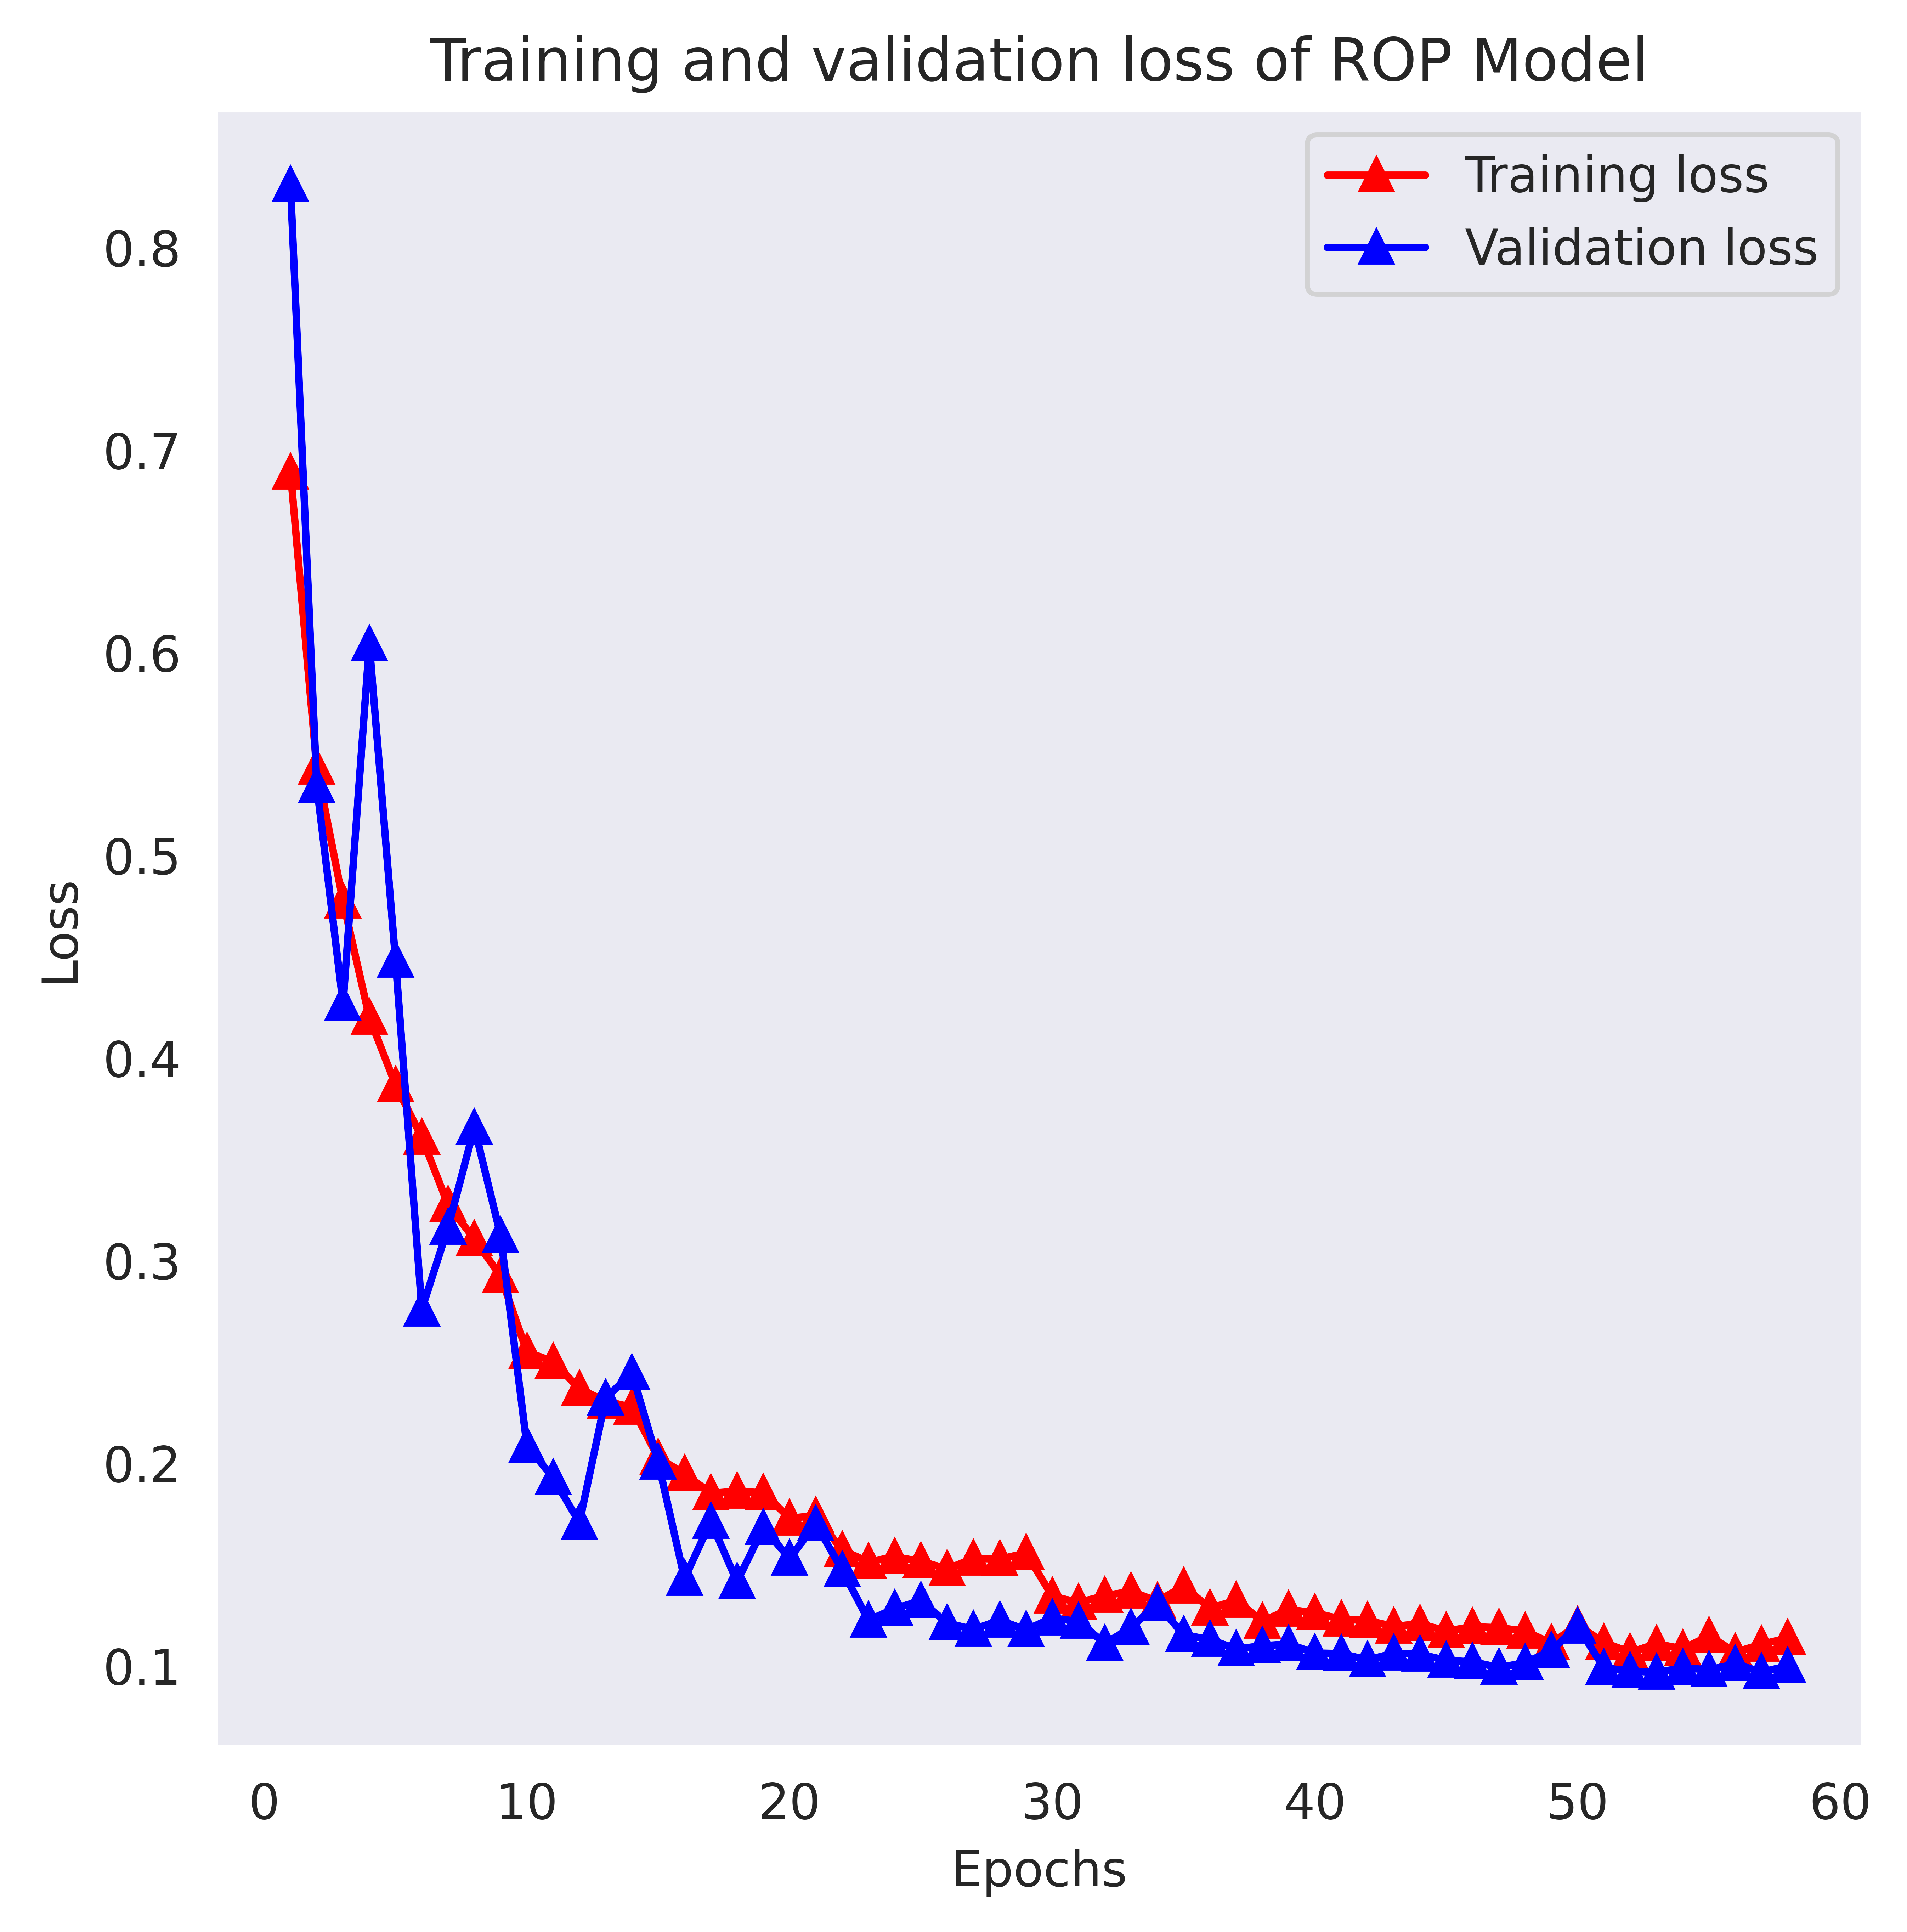

In [41]:
accuracy = history.history['accuracy']
valid_accuracy = history.history['val_accuracy']
loss = history.history['loss']
valid_loss = history.history['val_loss']

epochs = range(1, len(accuracy) + 1)

# Plot accuracy
plt.figure(figsize=(6, 6), dpi=1000)
plt.plot(epochs, accuracy, 'r^-', label='Training accuracy')  # Red pyramid marker and line for training accuracy
plt.plot(epochs, valid_accuracy, 'b^-', label='Validation accuracy')  # Blue pyramid marker and line for validation accuracy
plt.title('Training and validation accuracy of ROP model')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(False)  # Remove grid
plt.savefig('accuracy_plot.png', bbox_inches='tight')  # Save the plot
plt.show()

# Plot loss
plt.figure(figsize=(6, 6), dpi=1000)
plt.plot(epochs, loss, 'r^-', label='Training loss')  # Red pyramid marker and line for training loss
plt.plot(epochs, valid_loss, 'b^-', label='Validation loss')  # Blue pyramid marker and line for validation loss
plt.title('Training and validation loss of ROP Model')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(False)  # Remove grid
plt.savefig('loss_plot.png', bbox_inches='tight')  # Save the plot
plt.show()

In [42]:
test_labels = test_gen_new.classes
predictions = model.predict(test_gen_new)
predicted_classes = np.argmax(predictions, axis=1)

56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 149ms/step


In [43]:
report = classification_report(test_labels, predicted_classes, target_names=list(test_gen_new.class_indices.keys()))
print(report)

              precision    recall  f1-score   support

           1       0.98      1.00      0.99       445
           2       1.00      0.98      0.99       445

    accuracy                           0.99       890
   macro avg       0.99      0.99      0.99       890
weighted avg       0.99      0.99      0.99       890



In [44]:
conf_matrix = confusion_matrix(test_labels, predicted_classes)

In [45]:
from sklearn.metrics import accuracy_score

# Calculate accuracy
test_accuracy = accuracy_score(test_labels, predicted_classes)

# Print the accuracy
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


Test Accuracy: 98.99%


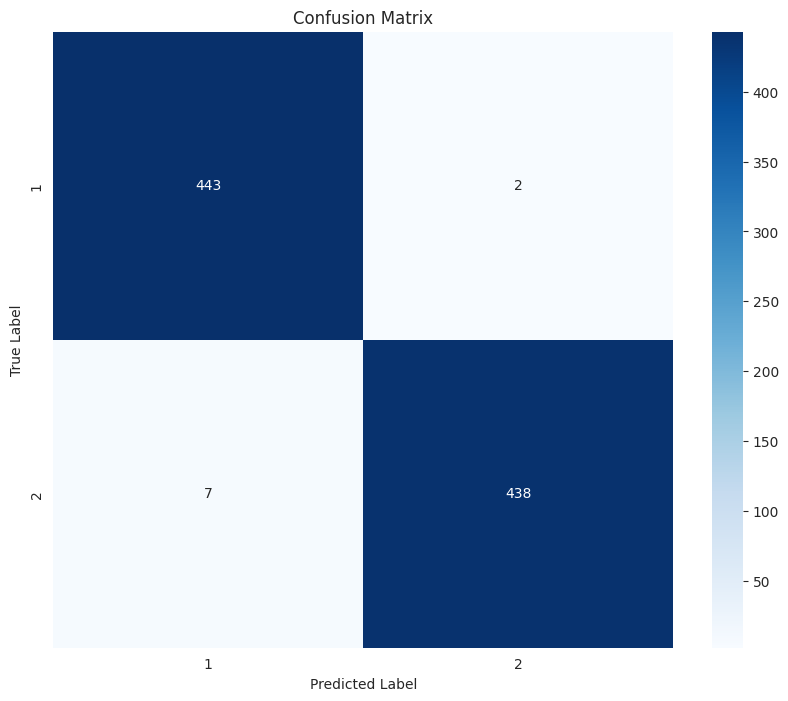

In [46]:
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=list(test_gen_new.class_indices.keys()), yticklabels=list(test_gen_new.class_indices.keys()))
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step


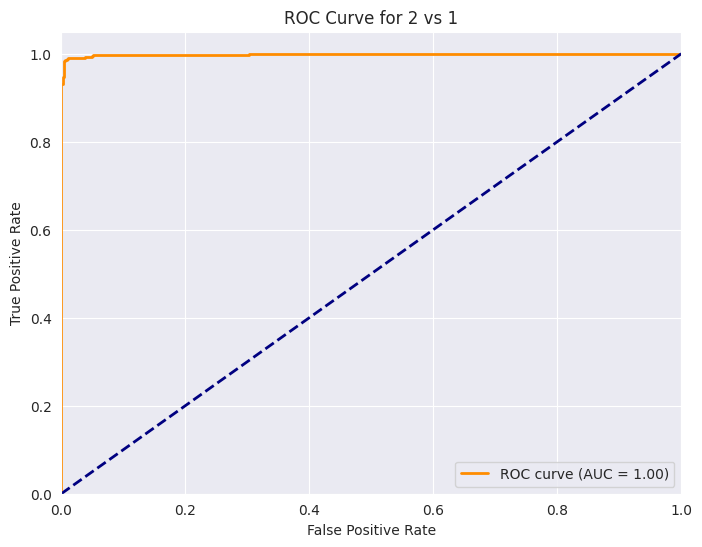

In [47]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import numpy as np

# Predict probabilities from the model
Y_score = model.predict(test_gen_new)

# Get class names and ensure correct index
class_names = list(test_gen_new.class_indices.keys())

# Get true binary labels (assuming binary classification: 0 or 1)
y_true = test_gen_new.classes  # Already in binary format (e.g., [0, 1, 1, 0,...])

# Get predicted scores for the positive class (e.g., class 1)
if Y_score.shape[1] == 2:
    y_score_pos = Y_score[:, 1]  # Probabilities for class 1
else:
    y_score_pos = Y_score.ravel()  # If model outputs a single column

# Compute ROC curve and AUC
fpr, tpr, _ = roc_curve(y_true, y_score_pos)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (AUC = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve for {class_names[1]} vs {class_names[0]}')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


In [48]:
model.save('content/Arsenic_CNN_dual_attention.h5')